# 🌾 Kaggriculture Imitation & Deep Reinforcement Learning Pipeline

## Hierarchical Dueling Double DQN with Autoregressive Market Actions

This notebook implements an enterprise-grade reinforcement learning training pipeline for the Kaggle **Kaggriculture** simulation environment. Rather than operating over an intractable flat discrete action space ($15 \times 15^6 \times 10 \approx 2.9 \times 10^{12}$ combinations), the model uses **hierarchical action branching** combined with a **Dueling Double Deep Q-Network (Dueling DDQN)**:

- **Farmer Action Branch**: Primary verb action space ($15$ discrete choices: movement, tile management, planting, harvesting).
- **Crop Parameter Branch**: State- and verb-conditioned crop selection ($5$ crop types), activated for farming verbs.
- **Hand Action Heads**: $6$ independent action heads ($15$ actions each) controlling specialized worker hands.
- **Autoregressive Market Decoder**: Recurrent GRU unrolling for sequential multi-order market transactions (up to $10$ orders per turn across $10$ discrete market operations).

---

### Directory & Environment Architecture

| Directory / Mount | Writable | Purpose |
|:---|:---:|:---|
| `/kaggle/input/` | **No** | Read-only input mounts. Episode JSONs: `/kaggle/input/kaggriculture-episodes-YYYY-MM-DD/{id}.json`. Code dataset: `kaggriculture-self-training-code`. Reference agents: `kaggriculture-reference-agents`. |
| `/kaggle/working/` | **Yes** | Working root for runtime modules, episode manifest cache (`kaggle_episodes/`), checkpoint states, and exported submissions (`run/agent.py`). |
| `~/kagg/experiments` | **Yes** | Local counterpart for active Player 1 candidate experiment runs and artifact generation. |
| `~/kagg/opponents` | **No** | Benchmark reference ladder opponents (Player 2 pool for Phase 3 league evaluation). |

---

### 🚀 Training Lifecycle Overview

1. **Phase 0 (Imitation Replay Bootstrap & BC Pretraining)**: Ingests 23,500+ top-ranked competitive human/bot games from the daily corpus into a Prioritized Replay Buffer (`PrioritizedReplayBuffer`), followed by Behavioral Cloning (BC) pretraining to prime advantage streams.
2. **Phase 1 (Self-Play Dueling DDQN)**: Online self-play against historical checkpoint opponents with Prioritized Experience Replay, kinematic reward shaping, and Double DQN greedy target alignment.
3. **Phase 2 (Submission Export & Checkpoint Serialization)**: Generates standalone submission `agent.py`, model weights `models/model.pth`, and training resume state `checkpoints/training_state_latest.pt`.
4. **Phase 3 (League Ladder Evaluation vs Reference Opponents)**: Head-to-head benchmarking against all 10 benchmark adversarial agents under `opponents/` (`fallow_finn`, `wheat_walter`, `rotation_rosa`, `homestead_hana`, `melon_mateo`, `rancher_rita`, `broker_bea`, `ledger_lena`, `slotter_silas`, `closer_cleo`).
5. **Phase 4 (Diagnostics, Visualization & Artifact Publishing)**: Renders 8 diagnostic training curves and synchronizes published artifacts.


## 1. Setup — Environment Deployment, Metadata Indexing & Hyperparameters

This stage initializes the training runtime, validates hardware acceleration, configures path bindings, and builds the training configuration:

- **Module Synchronization**: Deploys modular training scripts from `code_src` into `/kaggle/working` and configures `sys.path`.
- **Checkpoint Resumption**: Automatically discovers and restores existing weights (`model.pth`), training state (`training_state_latest.pt`), and incremental bootstrap progress (`bootstrap_state.json`).
- **Episode Corpus Indexing**: Merges daily episode manifests into `metadata.json` across all available calendar dates.
- **Hardware Preflight**: Validates GPU availability (CUDA / Apple Silicon MPS) and sets execution devices.

> **Training Mode Presets:**
> - `dry_run`: 1 bootstrap day, 50 BC steps, 2 self-play episodes (~1 min smoke test).
> - `medium` *(default)*: 5 bootstrap days, 1 BC epoch, 25 self-play episodes (~2–3 hours).
> - `full`: 5 bootstrap days, 2 BC epochs, 100 self-play episodes (extended training).


In [1]:
import json
import os
import subprocess
import sys
from pathlib import Path

import torch

# ── 1. Locate Code Dataset & Deploy Modules ──────────────────────────────
def _bootstrap_code_src() -> Path:
    candidates = [
        Path("/kaggle/input/datasets/scottweeden/kaggriculture-self-training-code"),
        Path("/kaggle/input/datasets/scottweeden/self-training-code"),
        Path("/kaggle/input/kaggriculture-self-training-code"),
        Path("/kaggle/input/self-training-code"),
        Path("~/kagg/datasets/scottweeden/self-training-code").expanduser(),
        Path("~/kagg/datasets/scottweeden/kaggriculture-self-training-code").expanduser(),
        Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd(),
    ]
    for p in candidates:
        if (p / "notebook_paths.py").exists():
            return p.resolve()
    tried = ", ".join(str(p) for p in candidates)
    raise FileNotFoundError(f"Missing code dataset. Tried: {tried}. Attach scottweeden/self-training-code.")

CODE_SRC = _bootstrap_code_src()
if str(CODE_SRC) not in sys.path:
    sys.path.insert(0, str(CODE_SRC))

from notebook_paths import (
    bust_stale_modules,
    configure_notebook_sys_path,
    deploy_training_code,
    kaggle_input_root,
    kaggle_working_root,
    experiment_dir as get_experiment_dir,
    metadata_dir as get_metadata_dir,
)

KAGGLE_INPUT = kaggle_input_root()
KAGGLE_WORKING = kaggle_working_root()
EXPERIMENT_DIR = get_experiment_dir(KAGGLE_WORKING)
METADATA_DIR = get_metadata_dir(KAGGLE_WORKING)
METADATA_PATH = METADATA_DIR / "metadata.json"

# Deploy training code and configure paths
deploy_training_code(CODE_SRC, KAGGLE_WORKING)
configure_notebook_sys_path(CODE_SRC, KAGGLE_WORKING)
bust_stale_modules()

print(f"Code dataset source (read-only): {CODE_SRC}")
print(f"Working directory (writable): {KAGGLE_WORKING}")
print(f"Experiment root: {EXPERIMENT_DIR}")

# ── 2. Import Training & Catalog Components ───────────────────────────────
from episode_catalog import (
    DEFAULT_END_DATE,
    DEFAULT_START_DATE,
    kaggle_daily_dataset_dir,
    merge_episode_metadata,
    pick_next_bootstrap_days,
    resolve_episode_paths_from_metadata,
    save_metadata,
)
from eval_policy import resolve_opponents_dir
from kaggriculture_self_play_training import train_self_play
from kaggriculture_dataset_publish import restore_training_artifacts_from_code_dataset

# ── 3. Configure Training Mode & Presets ──────────────────────────────────
# Production default: medium (~1–2 h). Set KAGGLE_TRAINING_MODE=dry_run for smoke tests only.
TRAINING_MODE = os.environ.get("KAGGLE_TRAINING_MODE", "medium")
if TRAINING_MODE not in ("dry_run", "medium", "full"):
    raise ValueError(
        f"KAGGLE_TRAINING_MODE={TRAINING_MODE!r} invalid; use dry_run, medium, or full"
    )

MODE_PRESETS = {
    "dry_run": {
        "bootstrap_mode": "daily_incremental",
        "bootstrap_days_per_run": 1,
        "bootstrap_episodes": None,
        "bootstrap_top_per_day": None,
        "bootstrap_passes": 1,
        "bootstrap_transitions": None,
        "buffer_capacity": 10_000,
        "bc_epochs_per_pass": 1,
        "bc_steps_per_epoch": 50,
        "total_episodes": 2,
        "learning_start_episodes": 99,
        "n_eval_episodes": 1,
        "ladder_eval_episodes": 1,
        "max_episode_steps": 50,
        "_eta": "~1 minute",
    },
    "medium": {
        "bootstrap_mode": "daily_incremental",
        "bootstrap_days_per_run": 5,
        "bootstrap_episodes": None,
        "bootstrap_top_per_day": None,
        "bootstrap_passes": 1,
        "bootstrap_transitions": None,
        "buffer_capacity": 200_000,
        "bc_epochs_per_pass": 1,
        "bc_steps_per_epoch": None,
        "total_episodes": 25,
        "learning_start_episodes": 5,
        "n_eval_episodes": 10,
        "ladder_eval_episodes": 2,
        "max_episode_steps": 720,
        "_eta": "~2–3 hours per 5-day batch",
    },
    "full": {
        "bootstrap_mode": "daily_incremental",
        "bootstrap_days_per_run": 5,
        "bootstrap_episodes": None,
        "bootstrap_top_per_day": None,
        "bootstrap_passes": 1,
        "bootstrap_transitions": None,
        "buffer_capacity": 600_000,
        "bc_epochs_per_pass": 2,
        "bc_steps_per_epoch": None,
        "total_episodes": 100,
        "learning_start_episodes": 5,
        "n_eval_episodes": 20,
        "ladder_eval_episodes": 5,
        "max_episode_steps": 720,
        "_eta": "several hours per 5-day batch",
    },
}

_mode = MODE_PRESETS[TRAINING_MODE]
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

_restored = restore_training_artifacts_from_code_dataset(CODE_SRC, EXPERIMENT_DIR)
if _restored:
    print(f"Restored from code dataset training_artifacts/: {_restored}")

_resume_ckpt = EXPERIMENT_DIR / "checkpoints" / "training_state_latest.pt"
_bootstrap_state = EXPERIMENT_DIR / "metrics" / "bootstrap_state.json"
_opp_dir = resolve_opponents_dir(code_src=CODE_SRC)

TRAINING_CONFIG = {
    "experiment_dir": str(EXPERIMENT_DIR),
    "code_src": str(CODE_SRC),
    "use_kaggle_env": True,
    "bootstrap_mode": _mode["bootstrap_mode"],
    "bootstrap_days_per_run": _mode["bootstrap_days_per_run"],
    "bootstrap_episodes": _mode["bootstrap_episodes"],
    "bootstrap_top_per_day": _mode["bootstrap_top_per_day"],
    "bootstrap_passes": _mode["bootstrap_passes"],
    "bootstrap_transitions": _mode["bootstrap_transitions"],
    "buffer_capacity": _mode["buffer_capacity"],
    "bc_epochs": 0,
    "bc_epochs_per_pass": _mode["bc_epochs_per_pass"],
    "bc_steps_per_epoch": _mode["bc_steps_per_epoch"],
    "data_dir": str(METADATA_DIR),
    "metadata_path": str(METADATA_PATH),
    "download_bootstrap": False,
    "bc_batch_size": 64,
    "total_episodes": _mode["total_episodes"],
    "learning_start_episodes": _mode["learning_start_episodes"],
    "batch_size": 32,
    "checkpoint_interval": 10,
    "n_eval_episodes": _mode["n_eval_episodes"],
    "ladder_eval_episodes": _mode.get("ladder_eval_episodes", 2),
    "ladder_win_rate_target": 0.75,
    "opponents_dir": str(_opp_dir) if _opp_dir else None,
    "max_episode_steps": _mode["max_episode_steps"],
    "device_name": "auto",
    "seed": 42,
    "resume": str(EXPERIMENT_DIR) if (_resume_ckpt.exists() or _restored) else None,
    "publish_code_dataset": TRAINING_MODE != "dry_run",
    "verbose": True,
}

print(f"=== TRAINING_MODE={TRAINING_MODE!r} ({_mode['_eta']}) ===")
if _mode["bootstrap_mode"] == "daily_incremental":
    print(
        f"  Daily bootstrap: {_mode['bootstrap_days_per_run']} chronological unseen day(s)/run, "
        f"all episodes/day, bc_epochs/day={_mode['bc_epochs_per_pass']}, "
        f"bc_steps={_mode['bc_steps_per_epoch'] or 'all'}"
    )
    if _bootstrap_state.exists():
        _bs = json.loads(_bootstrap_state.read_text())
        _done = _bs.get("bootstrapped_dates", [])
        print(f"  Bootstrapped days ({len(_done)}): {_done}")
    if TRAINING_CONFIG["resume"]:
        print(f"  Resume checkpoint: {_resume_ckpt}")
else:
    print(
        f"  Bootstrap: {_mode['bootstrap_passes']} passes × {_mode['bootstrap_transitions']:,} trans/pass "
        f"(buffer {_mode['buffer_capacity']:,})"
    )
print(
    f"  Self-play: {_mode['total_episodes']} episodes "
    f"(learn from ep {_mode['learning_start_episodes']}, "
    f"max_steps={_mode['max_episode_steps']}, eval={_mode['n_eval_episodes']})"
)
print(f"  Phase 3 Opponents: {_opp_dir or 'NOT FOUND'} (eval: {_mode.get('ladder_eval_episodes', 0)} ep/opponent)")

# ── 4. GPU Diagnostics ───────────────────────────────────────────────────
print("=== GPU diagnostics ===")
print(f"torch: {torch.__version__} (+cu{'yes' if '+cu' in torch.__version__ else '?'})")
print(f"torch.cuda.is_available(): {torch.cuda.is_available()}")
print(f"KAGGLE_KERNEL_RUN_TYPE: {os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '(unset)')}")
print(f"NVIDIA_VISIBLE_DEVICES: {os.environ.get('NVIDIA_VISIBLE_DEVICES', '(unset)')}")
try:
    print(subprocess.check_output(["nvidia-smi", "-L"], text=True, stderr=subprocess.STDOUT).strip())
except Exception as exc:
    print(f"nvidia-smi: {exc}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif os.environ.get("KAGGLE_KERNEL_RUN_TYPE") == "Batch":
    raise RuntimeError(
        "No GPU in this Batch session (31 episode datasets attached). "
        "CLI push often schedules CPU-only workers for large multi-dataset kernels. "
        "Fix: open notebook on Kaggle → Settings → Accelerator → GPU T4 x2 → Save Version → Run All."
    )
else:
    print("WARNING: No GPU. Set Settings → Accelerator → GPU T4 x2, then restart session.")

# ── 5. Preflight & Metadata Indexing ─────────────────────────────────────
assert KAGGLE_INPUT.is_dir(), f"Missing {KAGGLE_INPUT}"
assert os.access(KAGGLE_WORKING, os.W_OK), f"Not writable: {KAGGLE_WORKING}"
example_episode_dir = kaggle_daily_dataset_dir(DEFAULT_END_DATE)
if not example_episode_dir.is_dir():
    print(f"Note: episode mount not present at {example_episode_dir} (running locally/offline)")

EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)
metadata = merge_episode_metadata(
    data_dir=METADATA_DIR,
    start_date=DEFAULT_START_DATE,
    end_date=DEFAULT_END_DATE,
)
save_metadata(metadata, METADATA_PATH)

print(f"Code (input): {CODE_SRC}")
print(f"Episode mount example (input): {example_episode_dir}")
print(f"Metadata cache (working): {METADATA_DIR}")
print(f"Experiment output (working): {EXPERIMENT_DIR}")
print(f"Episodes indexed: {metadata['total_episodes_indexed']:,}")

_cfg_bc_steps = TRAINING_CONFIG.get("bc_steps_per_epoch") or "all"
if _mode["bootstrap_mode"] == "daily_incremental":
    _done = []
    if _bootstrap_state.exists():
        _done = json.loads(_bootstrap_state.read_text()).get("bootstrapped_dates", [])
    _next = pick_next_bootstrap_days(metadata, n_days=_mode["bootstrap_days_per_run"], exclude_dates=_done)
    print(
        f"Bootstrap plan: daily_incremental, {_mode['bootstrap_days_per_run']} day(s)/run, "
        f"bc_epochs/day={_mode['bc_epochs_per_pass']}, bc_steps={_cfg_bc_steps}, "
        f"training_mode={TRAINING_MODE!r}"
    )
    print(f"  Already bootstrapped ({len(_done)}): {_done or '(none)'}")
    print(f"  Next days this run: {_next or '(corpus complete)'}")
else:
    episode_files = resolve_episode_paths_from_metadata(
        metadata,
        top_per_day=TRAINING_CONFIG["bootstrap_top_per_day"],
        max_episodes=TRAINING_CONFIG["bootstrap_episodes"],
    )
    _cfg_passes = TRAINING_CONFIG["bootstrap_passes"]
    _cfg_trans = TRAINING_CONFIG.get("bootstrap_transitions") or TRAINING_CONFIG["buffer_capacity"]
    print(f"Bootstrap episodes resolved: {len(episode_files):,}")
    print(
        f"Bootstrap plan: {_cfg_passes} passes × {_cfg_trans:,} trans/pass, "
        f"bc_steps_per_epoch={_cfg_bc_steps}, training_mode={TRAINING_MODE!r}"
    )
    if episode_files:
        print(f"  Sample: {episode_files[0]}")

print(f"Replay buffer capacity: {TRAINING_CONFIG['buffer_capacity']:,}")
print(json.dumps(TRAINING_CONFIG, indent=2))


Code dataset source (read-only): /Users/sweeden/kagg/datasets/scottweeden/self-training-code
Working directory (writable): /Users/sweeden/kagg/working
Experiment root: /Users/sweeden/kagg/working/run


Restored from code dataset training_artifacts/: ['metrics/bootstrap_state.json (merged)', 'models/model.pth', 'checkpoints/training_state_latest.pt', 'metrics/bc_pretrain.json', 'metrics/episode_metrics.json', 'metrics/training_progress.json', 'metrics/win_rate_eval.json', 'metrics/ladder_eval.json', 'metrics/run_stats_summary.json', 'config.json', 'agent.py', 'plots/']
=== TRAINING_MODE='dry_run' (~1 minute) ===
  Daily bootstrap: 1 chronological unseen day(s)/run, all episodes/day, bc_epochs/day=1, bc_steps=50
  Bootstrapped days (18): ['2026-07-30', '2026-07-31', '2026-08-01', '2026-08-02', '2026-08-03', '2026-08-04', '2026-08-05', '2026-08-06', '2026-08-07', '2026-08-08', '2026-08-09', '2026-08-10', '2026-08-11', '2026-08-12', '2026-08-13', '2026-08-14', '2026-08-15', '2026-08-16']
  Resume checkpoint: /Users/sweeden/kagg/working/run/checkpoints/training_state_latest.pt
  Self-play: 2 episodes (learn from ep 99, max_steps=50, eval=1)
  Phase 3 Opponents: /Users/sweeden/kagg/opponen

Code (input): /Users/sweeden/kagg/datasets/scottweeden/self-training-code
Episode mount example (input): /Users/sweeden/kagg/working/kaggle_episodes/kaggriculture-episodes-2026-08-31
Metadata cache (working): /Users/sweeden/kagg/working/kaggle_episodes
Experiment output (working): /Users/sweeden/kagg/working/run
Episodes indexed: 23,551
Bootstrap plan: daily_incremental, 1 day(s)/run, bc_epochs/day=1, bc_steps=50, training_mode='dry_run'
  Already bootstrapped (18): ['2026-07-30', '2026-07-31', '2026-08-01', '2026-08-02', '2026-08-03', '2026-08-04', '2026-08-05', '2026-08-06', '2026-08-07', '2026-08-08', '2026-08-09', '2026-08-10', '2026-08-11', '2026-08-12', '2026-08-13', '2026-08-14', '2026-08-15', '2026-08-16']
  Next days this run: ['2026-08-17']
Replay buffer capacity: 10,000
{
  "experiment_dir": "/Users/sweeden/kagg/working/run",
  "code_src": "/Users/sweeden/kagg/datasets/scottweeden/self-training-code",
  "use_kaggle_env": true,
  "bootstrap_mode": "daily_incremental",
  "boot

## 2. Training Pipeline Execution — Bootstrap, BC Pretrain & Self-Play Loop

This cell dispatches `train_self_play(**TRAINING_CONFIG)` to execute the complete reinforcement learning workflow:

1. **Dual-Source Prioritized Buffer**: Allocates capacity for bootstrap demonstrations (`SOURCE_BOOTSTRAP`) and self-play transitions (`SOURCE_SELFPLAY`).
2. **Behavioral Cloning Pretraining**: Optimizes multi-branch cross-entropy loss over top-tier player actions.
3. **Self-Play Training Loop**:
   - Environment rollouts in `KaggleCompetitiveEnv` with dynamic action masking.
   - Opponent coordination via `SelfPlayCoordinator` (4:1 historical-to-online schedule).
   - Multi-head Double DQN loss computation with importance-sampling TD-error updates.
   - Kinematic potential reward shaping across growth, conversion, and liquidation phases.
4. **League Evaluation**: Evaluates win rates against the benchmark opponent ladder (`eval_policy.py`).
5. **Submission Generation**: Exports `agent.py` and `models/model.pth` ready for Kaggle submission.


In [2]:
train_self_play(**TRAINING_CONFIG)

2026-09-01 22:56:51,781 [INFO] train_orchestrator: Experiment directory: /Users/sweeden/kagg/working/run


2026-09-01 22:56:51,849 [DEBUG] train_orchestrator: Verbose debug logging enabled


2026-09-01 22:56:51,849 [DEBUG] train_orchestrator: Training config: {
  "experiment_dir": "/Users/sweeden/kagg/working/run",
  "seed": 42,
  "device": "auto",
  "total_episodes": 2,
  "learning_start_episodes": 99,
  "batch_size": 32,
  "checkpoint_interval": 10,
  "use_kaggle_env": true,
  "kinematic_phase_a": 3,
  "kinematic_phase_b": 4,
  "kinematic_phase_c": 6,
  "turns_per_cycle": 24,
  "cycles_per_episode": 2,
  "max_episode_steps": 50,
  "n_eval_episodes": 1,
  "bootstrap_episodes": null,
  "bootstrap_transitions": null,
  "data_dir": "/Users/sweeden/kagg/working/kaggle_episodes",
  "download_bootstrap": false,
  "bc_epochs": 0,
  "bc_batch_size": 64,
  "bc_steps_per_epoch": 50,
  "buffer_capacity": 10000,
  "metadata_path": "/Users/sweeden/kagg/working/kaggle_episodes/metadata.json",
  "bootstrap_top_per_day": null,
  "bootstrap_passes": 1,
  "bc_epochs_per_pass": 1,
  "verbose": true,
  "code_src": "/Users/sweeden/kagg/datasets/scottweeden/self-training-code",
  "bootstrap_mo

2026-09-01 22:56:51,864 [INFO] train_orchestrator: Self-play pipeline running on device: mps


2026-09-01 22:56:51,930 [DEBUG] train_orchestrator: Model init: HierarchicalDQNBranching params=1716765 (1.72M) buffer_capacity=10000


...

2026-09-01 22:58:55,388 [INFO] visualize: Updated plot: /Users/sweeden/kagg/working/run/plots/run_self_play_episodes.png


2026-09-01 22:58:55,422 [INFO] visualize: Updated plot: /Users/sweeden/kagg/working/run/plots/run_win_rate_eval.png


2026-09-01 22:58:55,424 [INFO] visualize: Run stats/plots updated: 7 PNGs → /Users/sweeden/kagg/working/run/plots


2026-09-01 22:58:55,425 [INFO] train_orchestrator: Trend plots updated (7 files) → /Users/sweeden/kagg/working/run/plots


2026-09-01 22:58:55,425 [INFO] train_orchestrator: --- SELF-PLAY TRAINING LOOP COMPLETED ---


## 3. Phase 3 Results — League Ladder Benchmarking vs Reference Opponents

This section inspects and validates the head-to-head match evaluations against the 10 reference opponent agents located under `opponents/` (`raykkretzschmar/kaggriculture-reference-agents` on Kaggle):

- **Phase 3 Opponent Ladder**: Per-opponent head-to-head match statistics, win rate %, coin earnings, and cleared status.
- **BC Pretraining Metrics**: Reports total bootstrap transitions loaded and final pretraining loss.
- **Deployment Artifact Checklist**: Confirms the integrity of the submission files:
  - `agent.py` — Standalone submission agent exposing `agent(obs, cfg=None)`.
  - `models/model.pth` — Serialized PyTorch neural network weights.
  - `checkpoints/training_state_latest.pt` — Full resume checkpoint.
  - `config.json` — Hyperparameter and metadata manifest.


In [3]:
metrics_dir = EXPERIMENT_DIR / "metrics"

ladder_path = metrics_dir / "ladder_eval.json"
if ladder_path.exists():
    ladder = json.loads(ladder_path.read_text())
    print("=" * 76)
    print("🏆 PHASE 3: LEAGUE LADDER EVALUATION VS REFERENCE OPPONENTS")
    print("=" * 76)
    print(f"Opponents Directory: {ladder.get('opponents_dir')}")
    print(f"Total Matches: {ladder.get('n_episodes_total')} ({ladder.get('n_episodes_per_opponent')} per opponent across {ladder.get('n_opponents')} agents)")
    print(f"Overall League Record: {ladder.get('wins_total')}W - {ladder.get('losses_total')}L - {ladder.get('ties_total')}T")
    print(f"Opponents Cleared (≥{ladder.get('win_rate_target', 0.75):.0%}): {ladder.get('opponents_cleared')}/{ladder.get('n_opponents')}")
    print(f"Beats All Opponents: {ladder.get('beats_all_opponents')}")
    print("-" * 76)
    print(f"{'Opponent Agent':<22} | {'Win Rate':<10} | {'Record (W-L-T)':<16} | {'Status'}")
    print("-" * 76)
    for slug, res in (ladder.get("results") or {}).items():
        w = res.get("wins", 0)
        l = res.get("losses", 0)
        t = res.get("ties", 0)
        wr = res.get("win_rate", 0.0)
        rec = f"{w}W-{l}L-{t}T"
        status = "✅ CLEARED" if res.get("cleared") else "⏳ IN PROGRESS"
        print(f"{slug:<22} | {wr:>8.1%}  | {rec:<16} | {status}")
    print("=" * 76)

bc_path = metrics_dir / "bc_pretrain.json"
if bc_path.exists():
    bc = json.loads(bc_path.read_text())
    print("\n=== BC Pretrain ===")
    print(f"  Bootstrap transitions: {bc.get('bootstrap_transitions')}")
    print(f"  Final BC loss: {bc.get('final_loss'):.5f}")

wr_path = metrics_dir / "win_rate_eval.json"
if wr_path.exists():
    wr = json.loads(wr_path.read_text())
    print("\n=== Win-rate Summary ===")
    print(f"  Win Rate: {wr.get('win_rate', 0):.1%} ({wr.get('wins')}/{wr.get('n_episodes')})")

print("\n=== Submission Artifact Checklist ===")
for rel in ["agent.py", "models/model.pth", "checkpoints/training_state_latest.pt", "config.json"]:
    p = EXPERIMENT_DIR / rel
    print(f"  {'OK' if p.exists() else '--'} {rel}")


🏆 PHASE 3: LEAGUE LADDER EVALUATION VS REFERENCE OPPONENTS
Opponents Directory: /Users/sweeden/kagg/opponents
Total Matches: 10 (1 per opponent across 10 agents)
Overall League Record: 0W - 10L - 0T
Opponents Cleared (≥75%): 0/10
Beats All Opponents: False
----------------------------------------------------------------------------
Opponent Agent         | Win Rate   | Record (W-L-T)   | Status
----------------------------------------------------------------------------
fallow_finn            |     0.0%  | 0W-1L-0T         | ⏳ IN PROGRESS
wheat_walter           |     0.0%  | 0W-1L-0T         | ⏳ IN PROGRESS
rotation_rosa          |     0.0%  | 0W-1L-0T         | ⏳ IN PROGRESS
homestead_hana         |     0.0%  | 0W-1L-0T         | ⏳ IN PROGRESS
melon_mateo            |     0.0%  | 0W-1L-0T         | ⏳ IN PROGRESS
rancher_rita           |     0.0%  | 0W-1L-0T         | ⏳ IN PROGRESS
broker_bea             |     0.0%  | 0W-1L-0T         | ⏳ IN PROGRESS
ledger_lena            |     0.0%  

## 4. Diagnostics & Metric Visualization

This cell generates and displays comprehensive multi-panel diagnostic plots for training analysis:

- **Training Loss**: Step-wise Huber loss curve with moving averages.
- **Epsilon Decay**: Exploration schedule progression over training episodes.
- **Replay Buffer Capacity**: Buffer growth and partition filling dynamics.
- **Raw vs Shaped Rewards**: Evolution of game coin earnings vs potential-shaped guidance.
- **Win Rate vs Ladder**: Head-to-head win percentage against reference opponents.
- **BC Pretrain Loss**: Epoch-by-epoch Behavioral Cloning convergence curve.



TRAINING METRICS SUMMARY

Experiment: run
--------------------------------------------------
  Config: {
        "experiment_dir": "/Users/sweeden/kagg/working/run",
        "seed": 42,
        "device": "auto",
        "total_episodes": 2,
        "learning_start_episodes": 99,
        "batch_size": 32,
        "checkpoint_interval": 10,
        "use_kaggle_env": true,
        "kinematic_phase_a": 3,
        "kinematic_phase_b": 4,
        "kinematic_phase_c": 6,
        "turns_per_cycle": 24,
        "cycles_per_episode": 2,
        "max_episode_steps": 50,
        "n_eval_episodes": 1,
        "bootstrap_episodes": null,
        "bootstrap_transitions": null,
        "data_dir": "/Users/sweeden/kagg/working/kaggle_episodes",
        "download_bootstrap": false,
        "bc_epochs": 0,
        "bc_batch_size": 64,
        "bc_steps_per_epoch": 50,
        "buffer_capacity": 10000,
        "metadata_path": "/Users/sweeden/kagg/working/kaggle_episodes/metadata.json",
        "bootstra

2026-09-01 22:58:55,607 [INFO] visualize: Saved: /Users/sweeden/kagg/working/run/plots/run_training_loss.png


2026-09-01 22:58:55,652 [INFO] visualize: Saved: /Users/sweeden/kagg/working/run/plots/run_epsilon_decay.png


2026-09-01 22:58:55,702 [INFO] visualize: Saved: /Users/sweeden/kagg/working/run/plots/run_buffer_size.png


2026-09-01 22:58:55,758 [INFO] visualize: Saved: /Users/sweeden/kagg/working/run/plots/run_eval_rewards.png


2026-09-01 22:58:55,832 [INFO] visualize: Saved: /Users/sweeden/kagg/working/run/plots/run_final_rewards.png


2026-09-01 22:58:55,916 [INFO] visualize: Saved: /Users/sweeden/kagg/working/run/plots/run_self_play_episodes.png


2026-09-01 22:58:55,948 [INFO] visualize: Saved: /Users/sweeden/kagg/working/run/plots/run_win_rate_eval.png


Saved 7 plot(s) to /Users/sweeden/kagg/working/run/plots


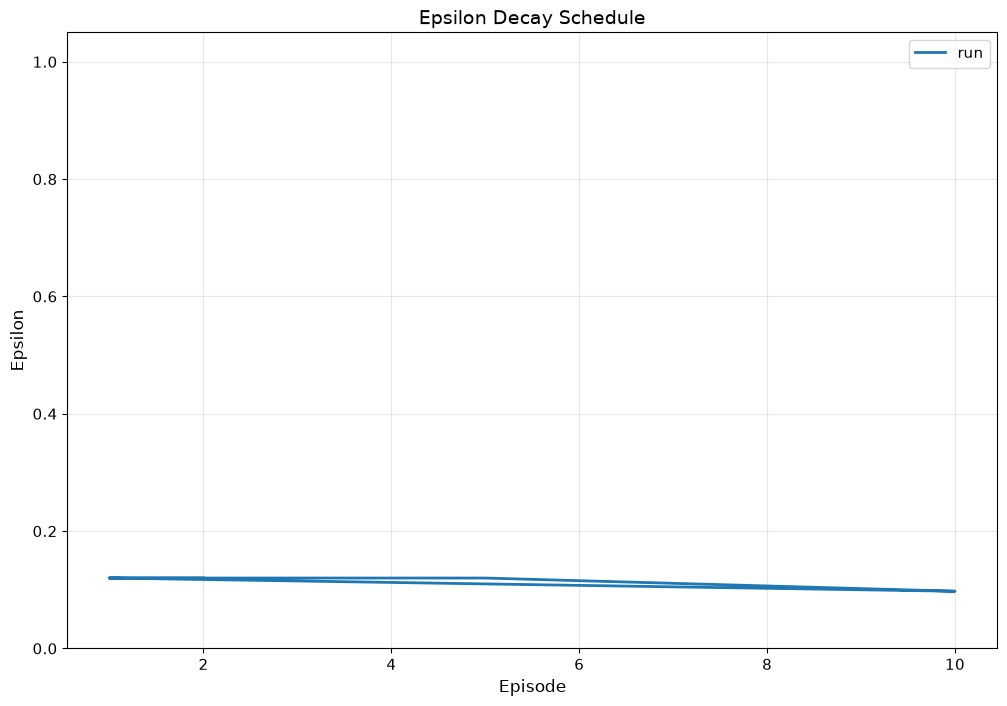

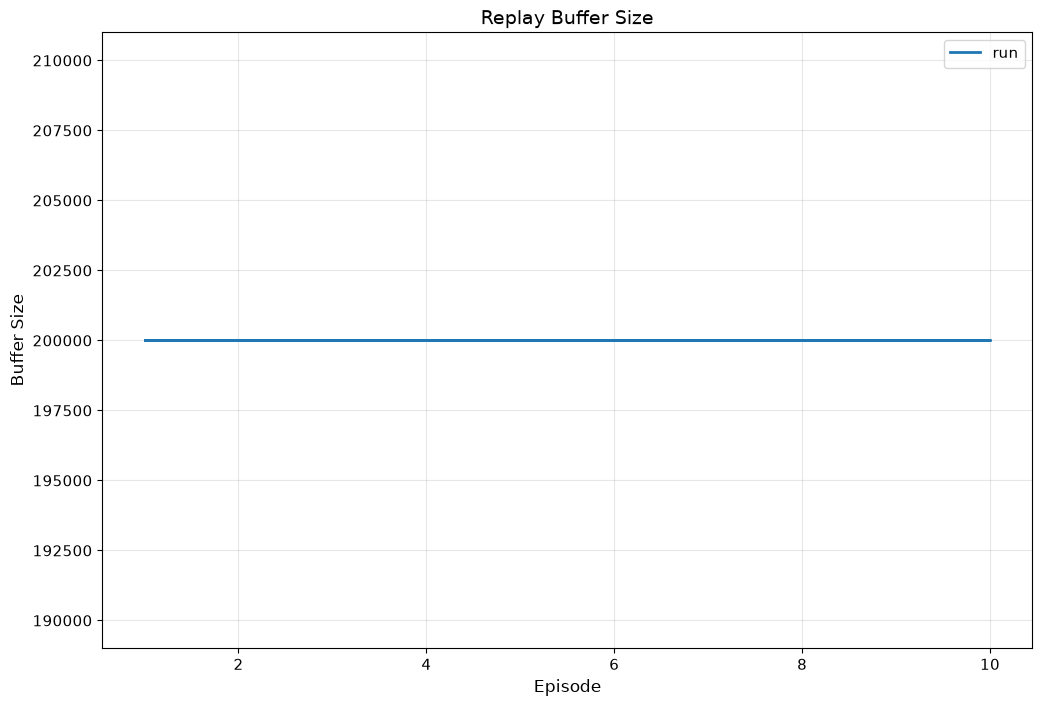

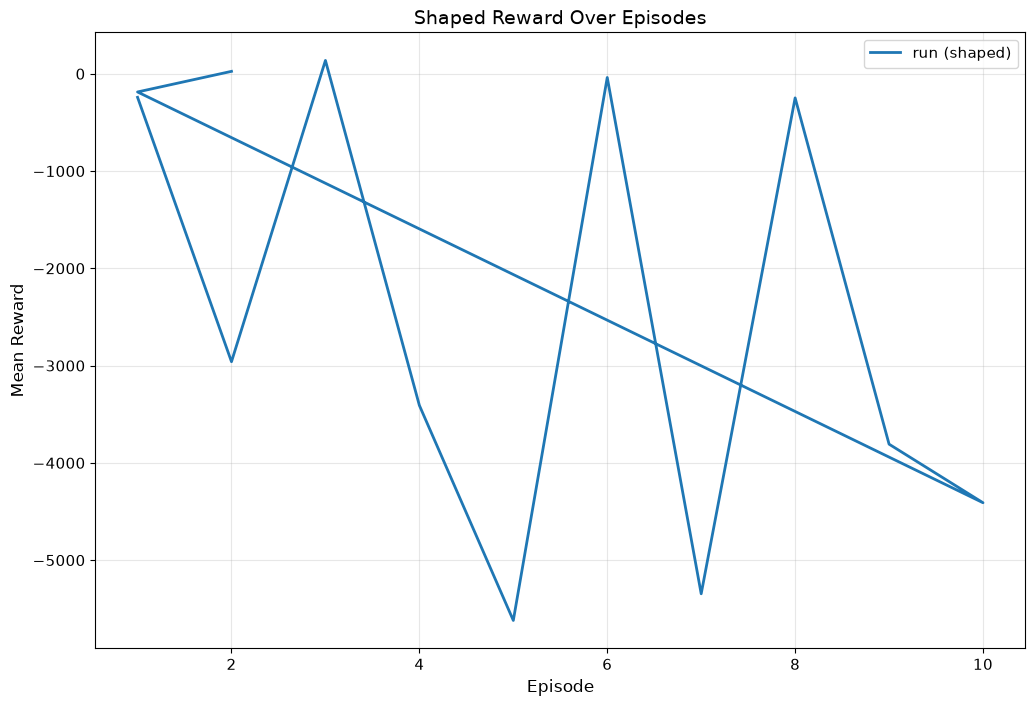

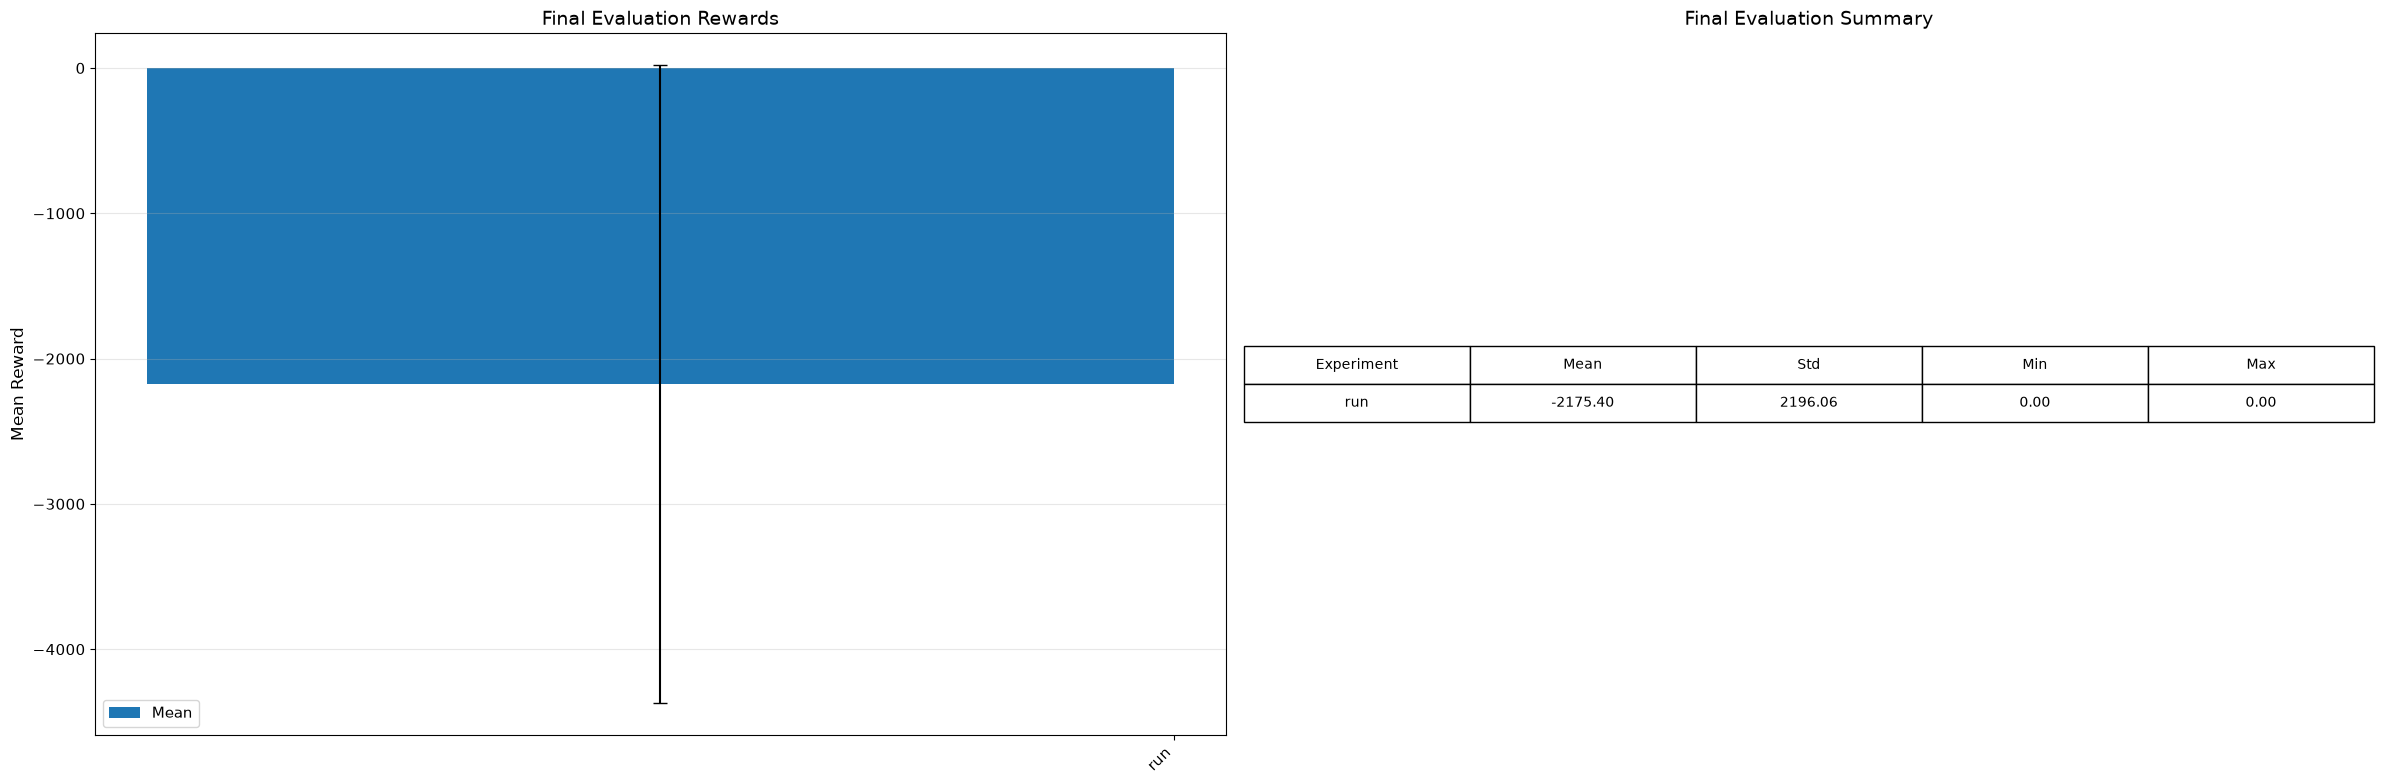

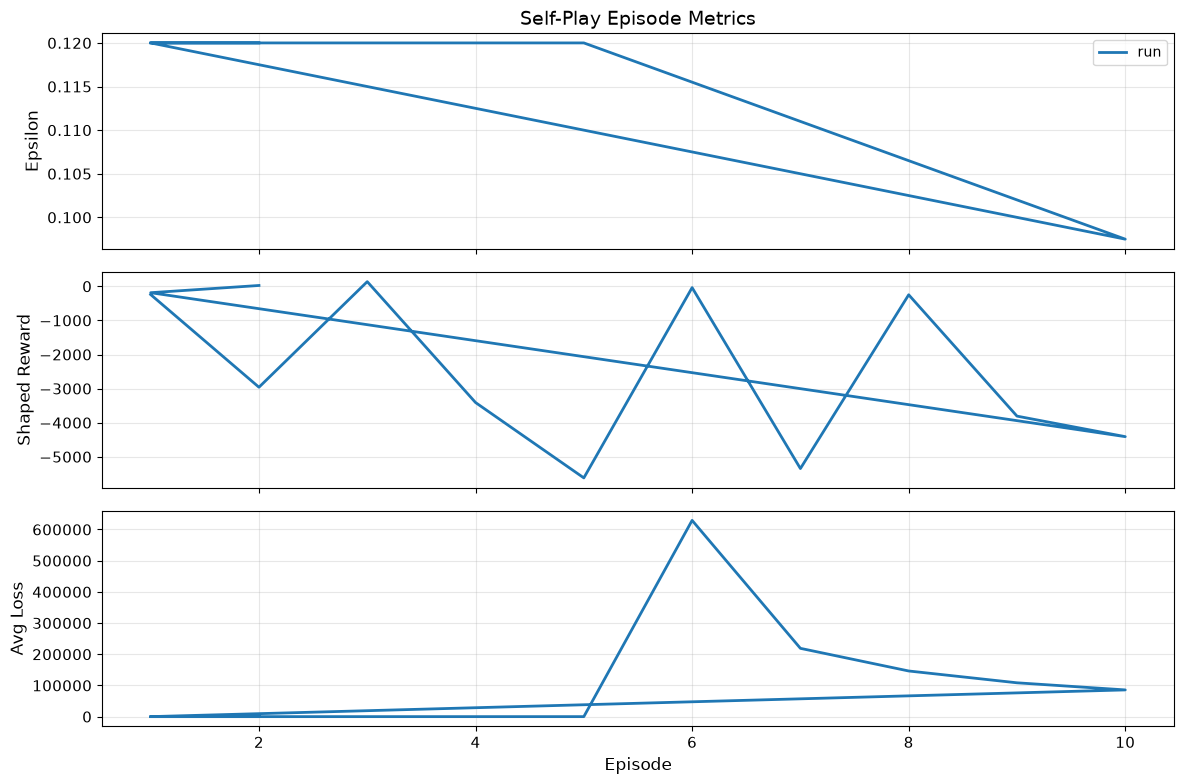

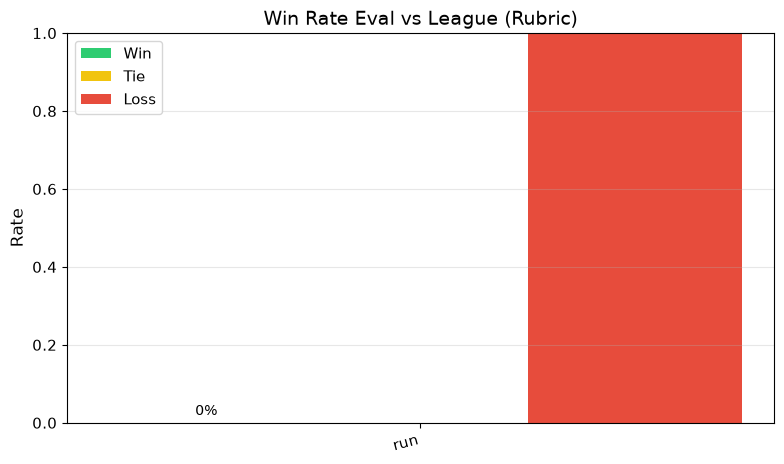

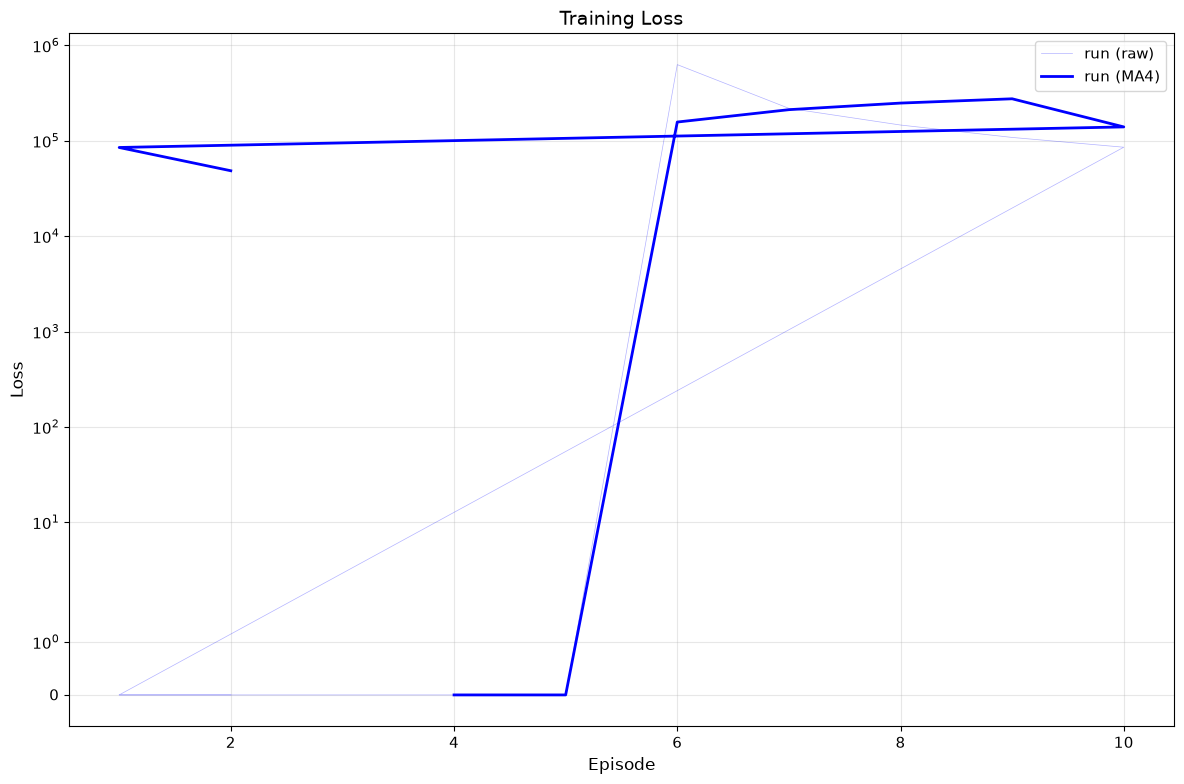

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Saved BC plot to /Users/sweeden/kagg/working/run/plots/bc_pretrain_loss.png


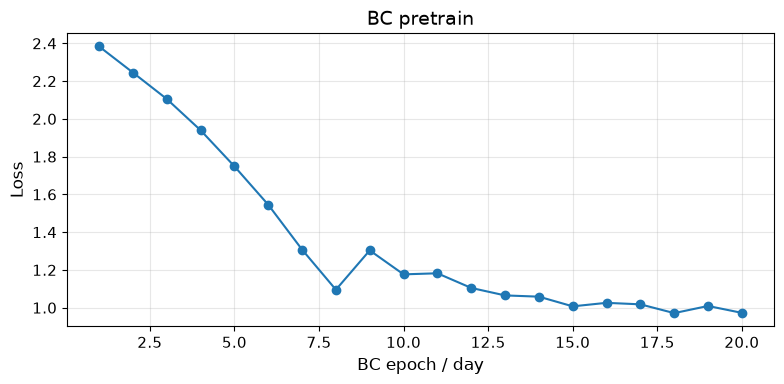

In [4]:
%matplotlib inline

import json
import shutil
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# Re-bootstrap if kernel restarted after long training (setup cell state lost)
try:
    from notebook_paths import kaggle_working_root, resolve_code_src, experiment_dir as get_experiment_dir
    KAGGLE_WORKING = kaggle_working_root()
    CODE_SRC = resolve_code_src()
except Exception:
    KAGGLE_WORKING = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("~/kagg/working").expanduser().resolve()
    CODE_SRC = next((p for p in [
        Path("/kaggle/input/datasets/scottweeden/kaggriculture-self-training-code"),
        Path("/kaggle/input/datasets/scottweeden/self-training-code"),
        Path("/kaggle/input/kaggriculture-self-training-code"),
        Path("~/kagg/datasets/scottweeden/self-training-code").expanduser(),
    ] if (p / "visualize.py").exists()), None)

if CODE_SRC and str(CODE_SRC) not in sys.path:
    sys.path.insert(0, str(CODE_SRC))
if KAGGLE_WORKING and str(KAGGLE_WORKING) not in sys.path:
    sys.path.insert(0, str(KAGGLE_WORKING))

if CODE_SRC and not (KAGGLE_WORKING / "visualize.py").exists():
    shutil.copy2(CODE_SRC / "visualize.py", KAGGLE_WORKING / "visualize.py")

EXPERIMENT_DIR = globals().get("EXPERIMENT_DIR", KAGGLE_WORKING / "run")

from visualize import TrainingMetricsLoader, MetricsVisualizer

PLOT_DIR = EXPERIMENT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
metrics_dir = EXPERIMENT_DIR / "metrics"

loader = TrainingMetricsLoader([str(EXPERIMENT_DIR)])
loader.load_all()

if loader.metrics:
    viz = MetricsVisualizer(output_dir=PLOT_DIR, figure_size=(12, 8))
    viz.print_summary(loader)
    figures = viz.plot_comparison(loader)
    if figures:
        exp_names = list(loader.metrics.keys())
        viz.save_figures(figures, exp_names, close=False)
        print(f"Saved {len(figures)} plot(s) to {PLOT_DIR}")
        for fig in figures:
            plt.figure(fig.number)
            plt.tight_layout()
            plt.show()
    else:
        print("No Path B metrics to plot yet — run training first.")
else:
    print(f"No metrics under {EXPERIMENT_DIR}")

bc_path = metrics_dir / "bc_pretrain.json"
if bc_path.exists():
    bc = json.loads(bc_path.read_text())
    losses = bc.get("epoch_losses") or bc.get("stream_stats", {}).get("epoch_losses", [])
    if losses:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(range(1, len(losses) + 1), losses, marker="o")
        ax.set(xlabel="BC epoch / day", ylabel="Loss", title="BC pretrain")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        bc_plot = PLOT_DIR / "bc_pretrain_loss.png"
        fig.savefig(bc_plot, dpi=150, bbox_inches="tight")
        print(f"Saved BC plot to {bc_plot}")
        plt.show()


## 5. Artifact Publishing & Checkpoint Synchronization

This stage packages and publishes updated training artifacts back to the Kaggle code dataset:

- Automatically packages `agent.py`, `models/model.pth`, `checkpoints/`, `metrics/`, and diagnostic `plots/`.
- In incremental training loops, this enables subsequent notebook runs to resume from the latest model checkpoint without re-running completed bootstrap days.
- *(Note: Skipped automatically when running in `dry_run` mode).*


In [5]:
import os
import shutil
import sys
from pathlib import Path

try:
    from notebook_paths import kaggle_working_root, resolve_code_src, experiment_dir as get_experiment_dir
    KAGGLE_WORKING = kaggle_working_root()
    CODE_SRC = resolve_code_src()
except Exception:
    KAGGLE_WORKING = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("~/kagg/working").expanduser().resolve()
    CODE_SRC = next((p for p in [
        Path("/kaggle/input/datasets/scottweeden/kaggriculture-self-training-code"),
        Path("/kaggle/input/datasets/scottweeden/self-training-code"),
        Path("/kaggle/input/kaggriculture-self-training-code"),
        Path("~/kagg/datasets/scottweeden/self-training-code").expanduser(),
    ] if (p / "kaggriculture_dataset_publish.py").exists()), None)

if CODE_SRC and str(CODE_SRC) not in sys.path:
    sys.path.insert(0, str(CODE_SRC))
if KAGGLE_WORKING and str(KAGGLE_WORKING) not in sys.path:
    sys.path.insert(0, str(KAGGLE_WORKING))

if CODE_SRC and not (KAGGLE_WORKING / "kaggriculture_dataset_publish.py").exists():
    shutil.copy2(CODE_SRC / "kaggriculture_dataset_publish.py", KAGGLE_WORKING / "kaggriculture_dataset_publish.py")

EXPERIMENT_DIR = globals().get("EXPERIMENT_DIR", KAGGLE_WORKING / "run")
TRAINING_MODE = globals().get("TRAINING_MODE", os.environ.get("KAGGLE_TRAINING_MODE", "medium"))

from kaggriculture_dataset_publish import (
    publish_training_artifacts_to_code_dataset,
    training_version_message,
)

if TRAINING_MODE == "dry_run":
    print("Skipping code dataset publish (dry_run mode)")
else:
    summary = publish_training_artifacts_to_code_dataset(
        EXPERIMENT_DIR,
        version_message=training_version_message(EXPERIMENT_DIR),
    )
    print("Published to scottweeden/kaggriculture-self-training-code")
    print(f"  Version: {summary['version_message']}")
    print("  Copied:")
    for item in summary["copied_artifacts"]:
        print(f"    - {item}")


Skipping code dataset publish (dry_run mode)
